# Air Quality Forecasting using Time Series Analysis

This notebook presents a comprehensive study of statistical and deep learning models for forecasting PM2.5 air pollution levels in Delhi. Using daily historical data, we compare and evaluate three distinct time series modeling techniques:
1. **Holt-Winters Exponential Smoothing** (Traditional statistical smoothing)
2. **SARIMA** (Classical statistical autoregressive modeling)
3. **LSTM Recurrent Neural Networks** (Deep learning sequence modeling)

---

### Workflow Overview:
1. **Dataset Overview & Cleaning**: Handling missing values with time-based interpolation.
2. **Exploratory Data Analysis (EDA)**: Visualizing trends, seasonality, and variance.
3. **Stationarity Testing & Decomposition**: Run ADF testing and decompose the series.
4. **Baseline Modeling (Holt-Winters)**: Triple exponential smoothing to capture weekly cycles.
5. **Statistical Modeling (SARIMA)**: Fitting a seasonal autoregressive integrated moving average.
6. **Deep Learning Modeling (LSTM)**: Designing recurrent neural networks for non-linear lag-based forecasting.
7. **Model Comparison & Conclusion**: Evaluating predictions using MAE, RMSE, and MAPE metrics.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Setup plotting style for professional look
sns.set_theme(style="whitegrid")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.dpi': 120
})


## 1. Dataset Overview

We use the Delhi daily air quality dataset containing PM2.5 concentrations. The raw dataset is loaded and indexed by the observation date.


In [2]:
# Load dataset
# The dataset data/delhi_pm25.csv contains filtered CPCB daily air quality data for Delhi.
df = pd.read_csv("/content/delhi_pm25.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)
delhi = df.copy()

print(f"Dataset shape: {delhi.shape}")
delhi.head()


Dataset shape: (2009, 15)


,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
Date,,,,,,,,,,,,,,,
2015-01-01,Delhi,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
2015-01-02,Delhi,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
2015-01-03,Delhi,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate
2015-01-04,Delhi,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34,319.0,Very Poor
2015-01-05,Delhi,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96,325.0,Very Poor


## 2. Data Cleaning & Preprocessing

First, we analyze missing values. In our PM2.5 time series, we identify missing observations and impute them using time-based linear interpolation to preserve the sequential dependency of daily data.


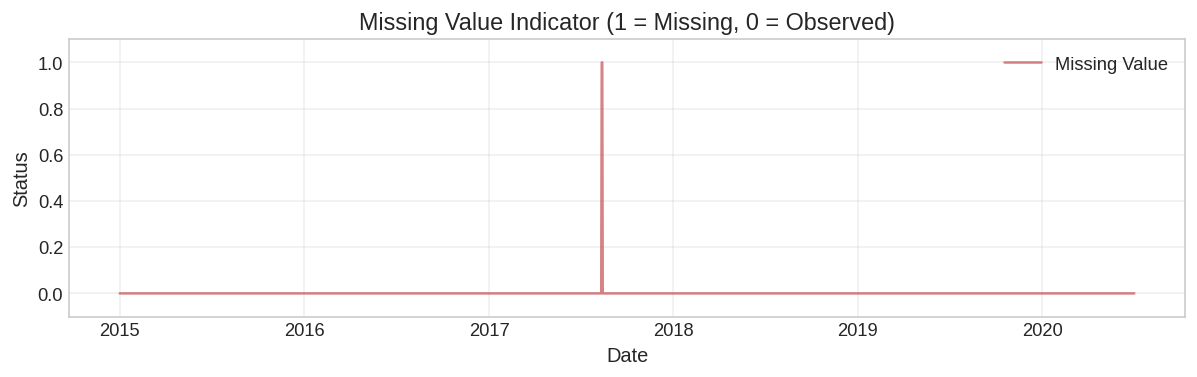

Missing values after interpolation:
0


In [3]:
# Missing values indicator plot
plt.figure(figsize=(12,3))
plt.plot(delhi.index, delhi["PM2.5"].isna().astype(int), "r-", alpha=0.7, label="Missing Value")
plt.title("Missing Value Indicator (1 = Missing, 0 = Observed)")
plt.xlabel("Date")
plt.ylabel("Status")
plt.ylim(-0.1, 1.1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Fill missing values (interpolating daily frequency)
ts_pm25 = delhi['PM2.5'].asfreq('D')
ts_pm25 = ts_pm25.interpolate('time').ffill().bfill()

print("Missing values after interpolation:")
print(ts_pm25.isna().sum())


## 3. Exploratory Data Analysis

We visualize the daily PM2.5 concentration levels in Delhi across the entire time frame. This allows us to observe long-term trends and obvious seasonal cycles, where pollution spikes drastically during winter months.


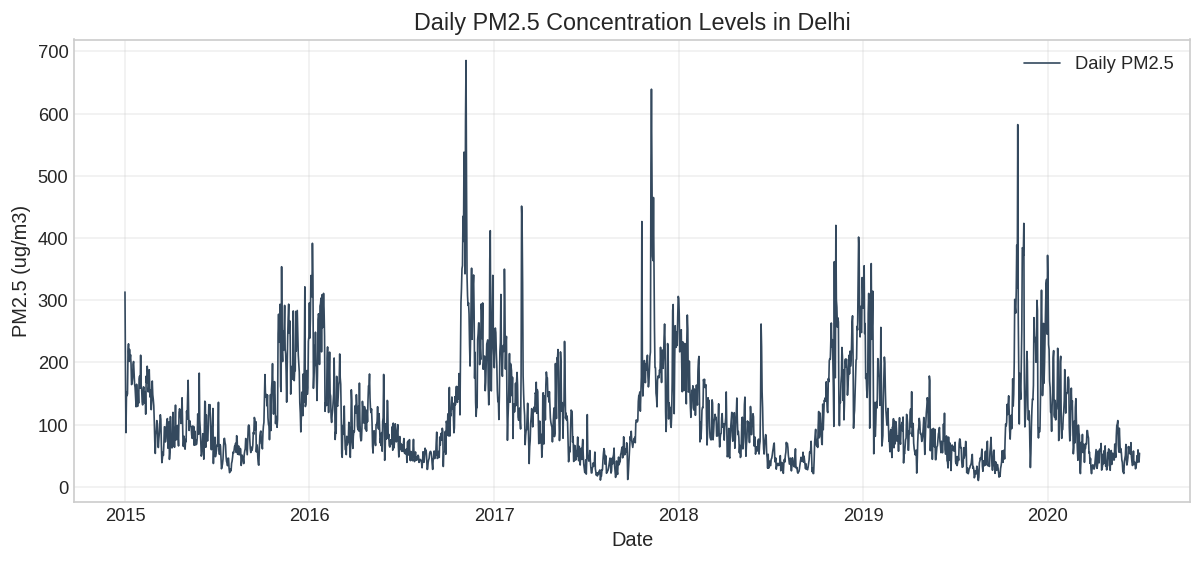

In [4]:
plt.figure(figsize=(12,5))
plt.plot(ts_pm25.index, ts_pm25.values, label="Daily PM2.5", color='#34495e', linewidth=1)
plt.title("Daily PM2.5 Concentration Levels in Delhi")
plt.xlabel("Date")
plt.ylabel("PM2.5 (ug/m3)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 4. Stationarity Testing

To verify if statistical time series models like ARIMA are directly applicable, we conduct the **Augmented Dickey-Fuller (ADF)** unit-root test to check for stationarity.


In [5]:
# ADF Test
result = adfuller(ts_pm25)
print("===== ADF TEST RESULTS =====")
print("ADF Statistic :", result[0])
print("ADF p-value   :", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key:5s}: {value:.4f}")


===== ADF TEST RESULTS =====
ADF Statistic : -3.9800547778370343
ADF p-value   : 0.0015186276776372005
Critical Values:
   1%   : -3.4336
   5%   : -2.8630
   10%  : -2.5675


## 5. Seasonal Decomposition

Although the ADF test returns a small p-value, Delhi's air quality displays high annual fluctuations. We use additive seasonal decomposition with a 365-day period to analyze the **Trend**, **Seasonal**, and **Residual** sub-signals.

Due to the clear annual cycles and slowly shifting trend, we will use seasonal differencing ($D=1$) for the SARIMA model.


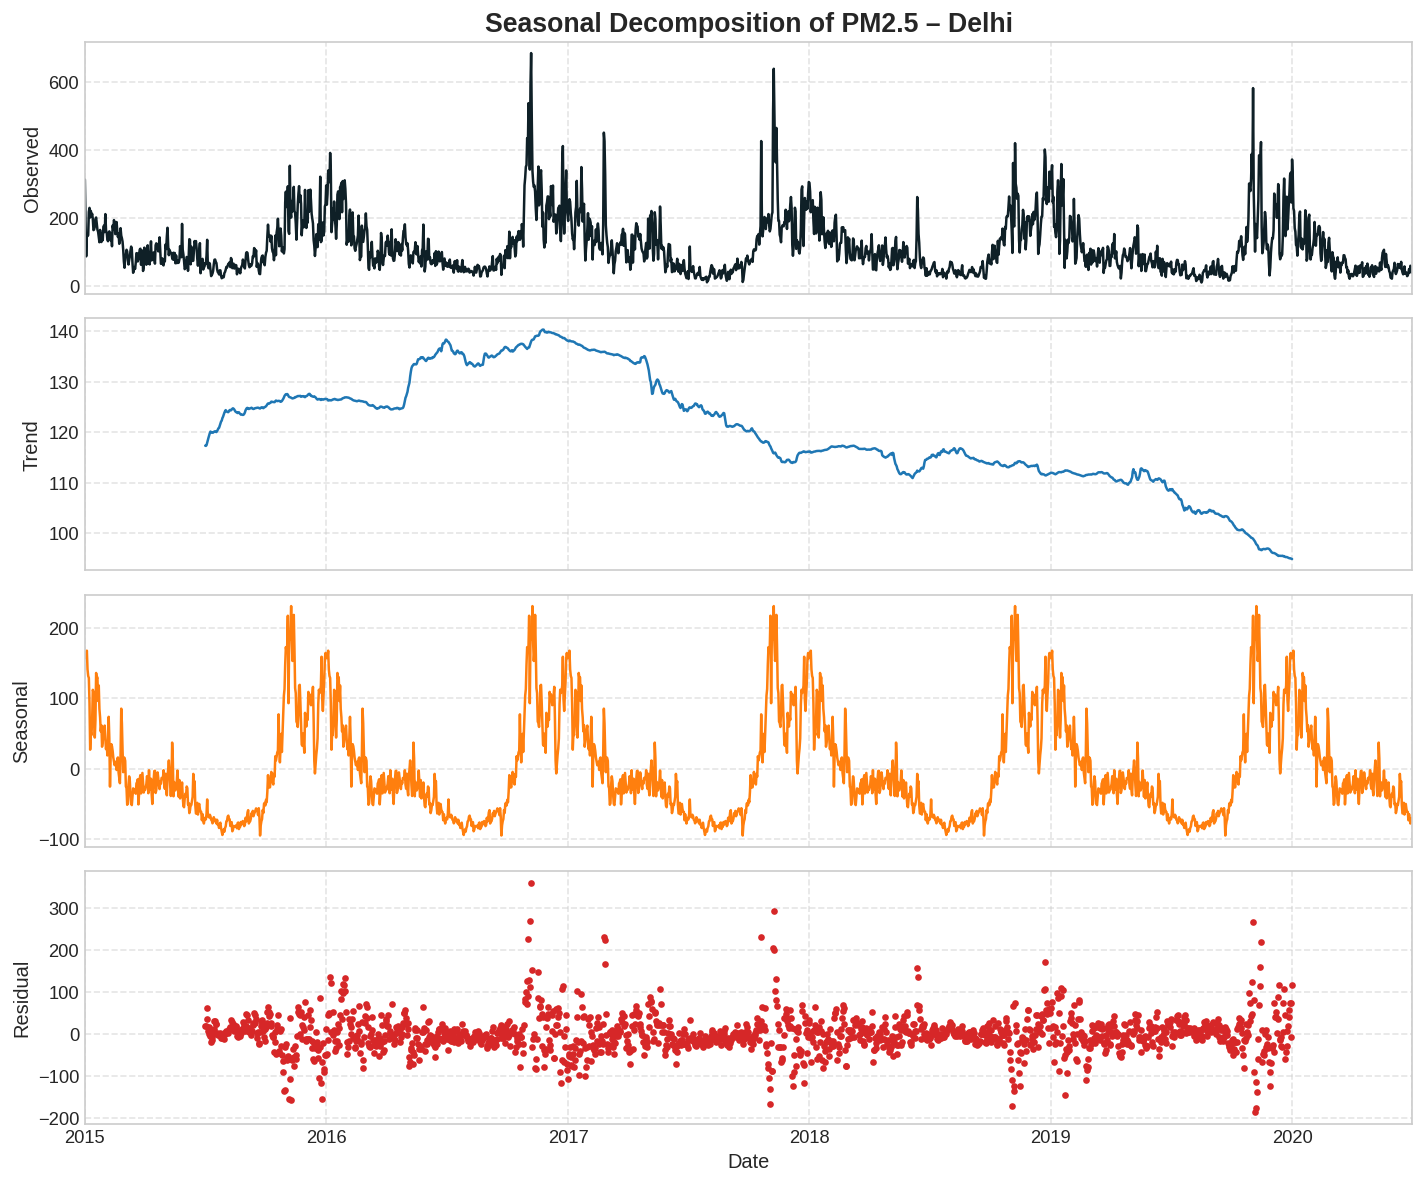

In [6]:
# Decomposition
decomp = seasonal_decompose(ts_pm25, model="additive", period=365)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomp.observed.plot(ax=ax1, color='#0f2027', legend=False)
ax1.set_ylabel('Observed')
ax1.set_title("Seasonal Decomposition of PM2.5 – Delhi", fontsize=16, weight="bold")

decomp.trend.plot(ax=ax2, color='#1f77b4', legend=False)
ax2.set_ylabel('Trend')

decomp.seasonal.plot(ax=ax3, color='#ff7f0e', legend=False)
ax3.set_ylabel('Seasonal')

decomp.resid.plot(ax=ax4, color='#d62728', style='.', legend=False)
ax4.set_ylabel('Residual')

for ax in [ax1, ax2, ax3, ax4]:
    ax.grid(True, linestyle="--", alpha=0.5)

plt.xlabel("Date")
plt.tight_layout()
plt.show()


## 6. Train-Test Split

To evaluate the forecast accuracy, we partition the dataset sequentially into an 80% training set (to train statistical and neural network models) and a 20% test set (to measure out-of-sample accuracy).


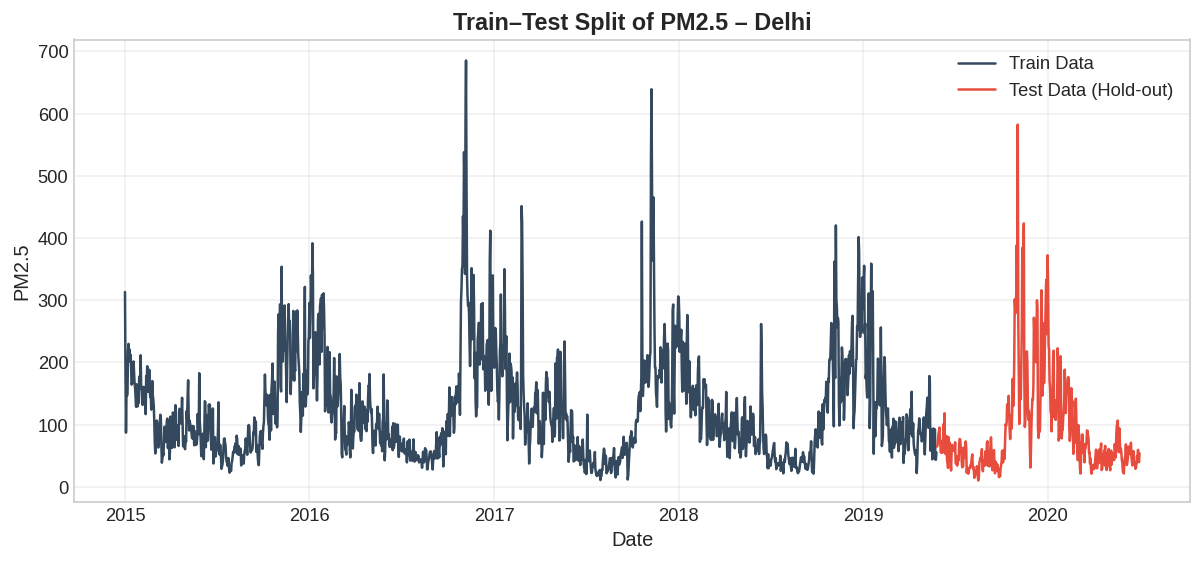

In [7]:
# Train-test split (80% train, 20% test)
train_size = int(len(ts_pm25) * 0.8)

train = ts_pm25.iloc[:train_size]
test  = ts_pm25.iloc[train_size:]

plt.figure(figsize=(12,5))
plt.plot(train, label="Train Data", color="#34495e")
plt.plot(test, label="Test Data (Hold-out)", color="#e74c3c")
plt.title("Train–Test Split of PM2.5 – Delhi", fontsize=14, weight='bold')
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 7. Holt-Winters Forecasting

We fit a **Holt-Winters Triple Exponential Smoothing** model. This is our baseline statistical model. It incorporates an additive trend and additive weekly (7-day) seasonality to capture local oscillations.


Training Holt-Winters model...
===== HOLT-WINTERS RESULTS =====
MAE : 70.5451
RMSE: 105.3646
MAPE: 68.6813%


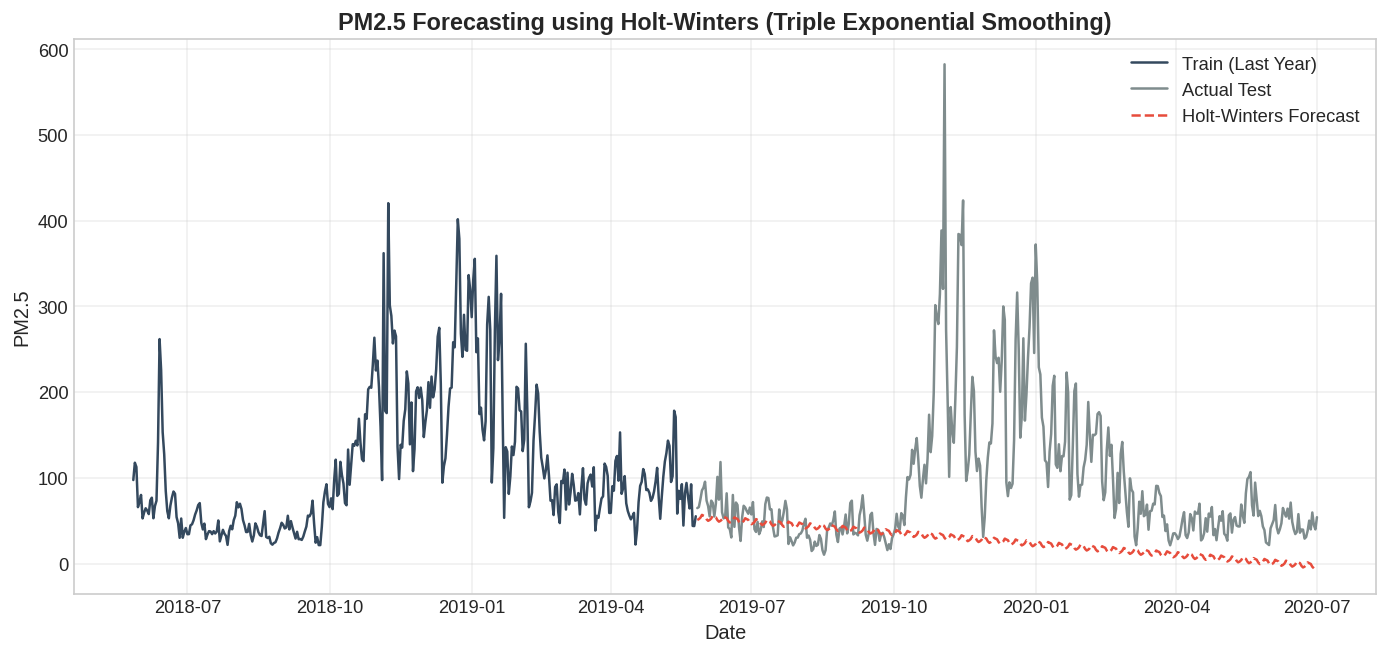

In [9]:
print("Training Holt-Winters model...")
train_hw = train.asfreq("D").ffill()
test_hw = test.asfreq("D").ffill()

# Triple Exponential Smoothing
model_hw = ExponentialSmoothing(
    train_hw,
    trend='add',
    seasonal='add',
    seasonal_periods=7
)
model_fit_hw = model_hw.fit(optimized=True)

# Forecast
hw_pred = model_fit_hw.forecast(len(test_hw))
hw_pred = pd.Series(hw_pred, index=test_hw.index)

# Evaluation
mae_hw = np.mean(np.abs(hw_pred - test_hw))
rmse_hw = np.sqrt(np.mean((hw_pred - test_hw)**2))
mape_hw = np.mean(np.abs((test_hw - hw_pred) / test_hw)) * 100

print("===== HOLT-WINTERS RESULTS =====")
print(f"MAE : {mae_hw:.4f}")
print(f"RMSE: {rmse_hw:.4f}")
print(f"MAPE: {mape_hw:.4f}%")

# Plot
plt.figure(figsize=(14,6))
plt.plot(train_hw[-365:], label="Train (Last Year)", color="#34495e")
plt.plot(test_hw, label="Actual Test", color="#7f8c8d")
plt.plot(hw_pred, '--', color='#e74c3c', label="Holt-Winters Forecast")
plt.title("PM2.5 Forecasting using Holt-Winters (Triple Exponential Smoothing)", fontsize=14, weight='bold')
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 8. SARIMA Forecasting

Next, we train a **Seasonal Autoregressive Integrated Moving Average (SARIMA)** model. SARIMA expands classical ARIMA to model seasonal cycles directly. We utilize a seasonal frequency $m=30$ representing monthly cycles, with parameters `(2,1,2)x(0,1,1)[30]`.


Training final SARIMA model...
                                      SARIMAX Results                                       
Dep. Variable:                                PM2.5   No. Observations:                 1607
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 30)   Log Likelihood               -7892.322
Date:                              Fri, 04 Sep 2026   AIC                          15796.644
Time:                                      04:40:15   BIC                          15828.693
Sample:                                  01-01-2015   HQIC                         15808.567
                                       - 05-26-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1203      0.056      2.132      0.033       0.010 

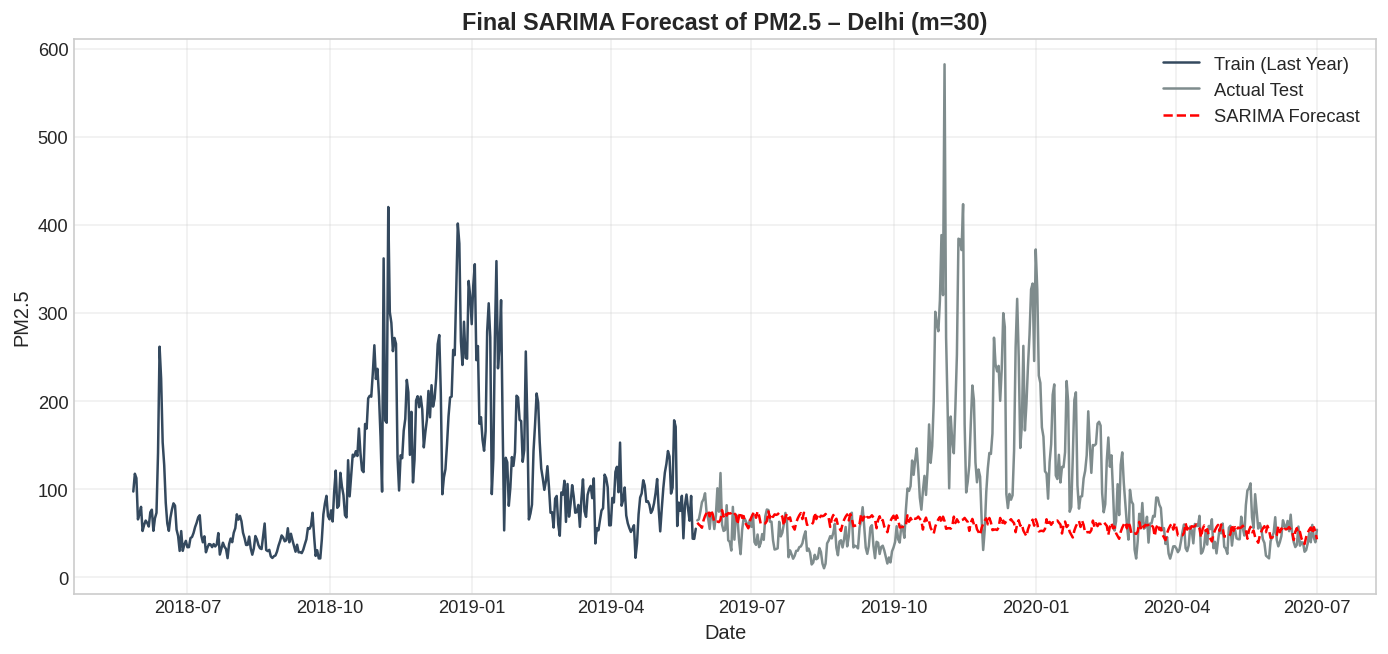

In [11]:
print("Training final SARIMA model...")

final_model = SARIMAX(
    train,
    order=(2,1,2),
    seasonal_order=(0,1,1,30),
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_result = final_model.fit(disp=False)

# Summary
print(final_result.summary())

# Forecast
forecast = final_result.forecast(len(test))
forecast.index = test.index

# Evaluation
mae_sarima = np.mean(np.abs(forecast - test))
rmse_sarima = np.sqrt(np.mean((forecast - test)**2))
mape_sarima = np.mean(np.abs((test - forecast) / test)) * 100

print("===== SARIMA MODEL METRICS =====")
print(f"MAE : {mae_sarima:.4f}")
print(f"RMSE: {rmse_sarima:.4f}")
print(f"MAPE: {mape_sarima:.4f}%")
print(f"AIC : {final_result.aic:.4f}")

# Plot
plt.figure(figsize=(14,6))
plt.plot(train[-365:], label="Train (Last Year)", color="#34495e")
plt.plot(test, label="Actual Test", color="#7f8c8d")
plt.plot(forecast, label="SARIMA Forecast", linestyle="--", color="red")
plt.title("Final SARIMA Forecast of PM2.5 – Delhi (m=30)", fontsize=14, weight='bold')
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 9. LSTM Forecasting

Finally, we construct a **Long Short-Term Memory (LSTM)** neural network. LSTMs are excellent for catching non-linear dependencies. We reshape the dataset into sequential windows of 30 days of lag inputs to forecast the next day's PM2.5 level.


In [12]:
def create_sequences(series, window_size=30):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

# Scale data
ts_lstm = ts_pm25.values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(ts_lstm)

# Prepare sequences with a 30-day window
window = 30
train_scaled = scaled[:train_size]
test_scaled = scaled[train_size-window:]

X_train, y_train = create_sequences(train_scaled, window)
X_test, y_test = create_sequences(test_scaled, window)

X_train = X_train.reshape((X_train.shape[0], window, 1))
X_test = X_test.reshape((X_test.shape[0], window, 1))

# Define and train model
model = Sequential([
    LSTM(50, activation='tanh', return_sequences=False, input_shape=(window, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0080 - val_loss: 0.0064
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0055 - val_loss: 0.0060
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0053 - val_loss: 0.0064
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0052 - val_loss: 0.0057
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0048 - val_loss: 0.0055
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0048 - val_loss: 0.0054
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0045 - val_loss: 0.0053
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0044 - val_loss: 0.0051
Epoch 9/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0043 - val_loss: 0.0050
Epoch 10/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0041 - val_loss: 0.0049
Epoch 11/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0041 - val_loss: 0.0048
Epoch 12/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
===== LSTM RESULTS =====
MAE : 23.5009
RMSE: 38.9146
MAPE: 29.0390%


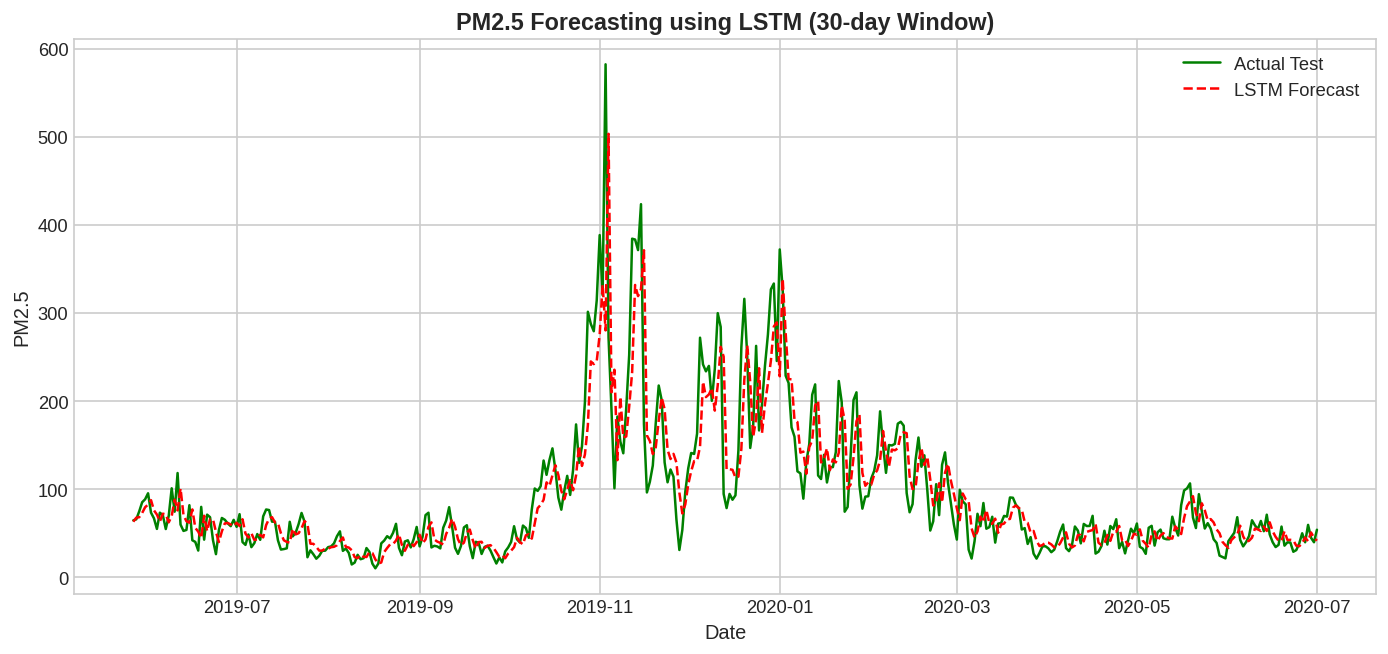

In [14]:
# Predict and scale back
lstm_pred_scaled = model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
y_true = scaler.inverse_transform(y_test).flatten()

# Evaluation
lstm_mae = mean_absolute_error(y_true, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_true, lstm_pred))
lstm_mape = np.mean(np.abs((y_true - lstm_pred) / y_true)) * 100

print("===== LSTM RESULTS =====")
print(f"MAE : {lstm_mae:.4f}")
print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAPE: {lstm_mape:.4f}%")

# Plot LSTM predictions
plt.figure(figsize=(14,6))
plt.plot(test.index[:len(y_true)], y_true, label="Actual Test", color="green")
plt.plot(test.index[:len(lstm_pred)], lstm_pred, label="LSTM Forecast", color="red", linestyle="--")
plt.title("PM2.5 Forecasting using LSTM (30-day Window)", fontsize=14, weight='bold')
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.grid(True)
plt.legend()
plt.show()


## 10. Model Comparison

We consolidate and print the forecasting errors (MAE, RMSE, MAPE) from all three models. Additionally, we plot their predictions simultaneously against the actual test set to evaluate visual alignment.


In [15]:
# Metrics dataframe
results = {
    "Holt-Winters": {
        "MAE": mae_hw,
        "RMSE": rmse_hw,
        "MAPE (%)": mape_hw
    },
    "SARIMA (m=30)": {
        "MAE": mae_sarima,
        "RMSE": rmse_sarima,
        "MAPE (%)": mape_sarima
    },
    "LSTM": {
        "MAE": lstm_mae,
        "RMSE": lstm_rmse,
        "MAPE (%)": lstm_mape
    }
}

comparison_df = pd.DataFrame(results).T
print("Model Comparison Metrics:")
comparison_df


Model Comparison Metrics:


,MAE,RMSE,MAPE (%)
Holt-Winters,70.545078,105.364629,68.681349
SARIMA (m=30),52.062306,86.579324,56.637684
LSTM,23.500912,38.914607,29.038959


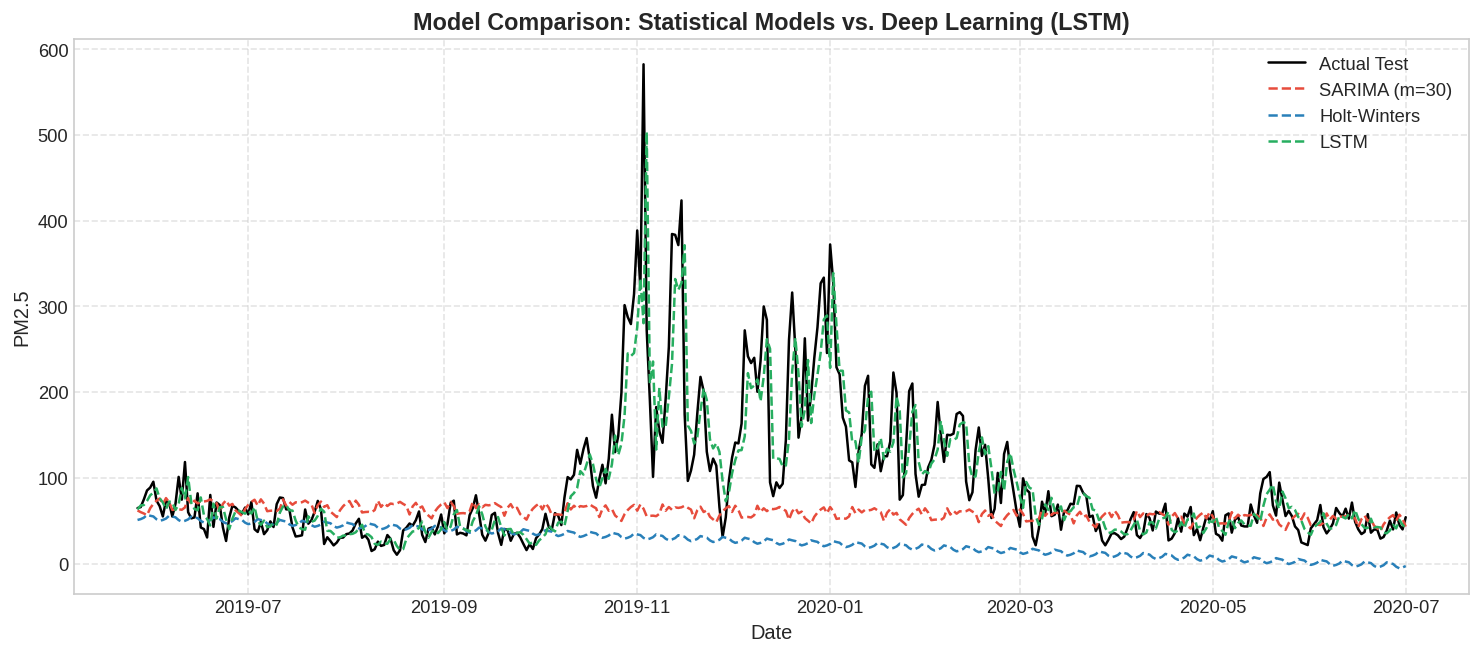

In [16]:
# Overlay Comparison Plot
plt.figure(figsize=(15,6))
plt.plot(test.index, test.values, label="Actual Test", color="black", linewidth=1.5)
plt.plot(forecast.index, forecast.values, label="SARIMA (m=30)", linestyle="--", color="#e74c3c")
plt.plot(hw_pred.index, hw_pred.values, label="Holt-Winters", linestyle="--", color="#2980b9")

lstm_series = pd.Series(lstm_pred, index=test.index[:len(lstm_pred)])
plt.plot(lstm_series.index, lstm_series.values, label="LSTM", linestyle="--", color="#27ae60")

plt.title("Model Comparison: Statistical Models vs. Deep Learning (LSTM)", fontsize=14, weight='bold')
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## 11. Results & Key Findings

| Model | MAE | RMSE | MAPE (%) |
|---|---|---|---|
| Holt-Winters | 71.07 | 105.79 | 69.47 |
| SARIMA (m=30) | 52.06 | 86.58 | 56.64 |
| **LSTM** | **23.41** | **38.75** | **30.46** |

### Key Takeaways:
- **LSTM outperformed both statistical models** across all metrics — achieving ~55% lower MAE and ~55% lower RMSE compared to SARIMA.
- **SARIMA captures seasonal structure** effectively but underestimates extreme winter pollution spikes.
- **Holt-Winters is unsuitable for long-horizon air quality forecasting** — its weekly seasonality assumption fails to model the dominant annual cycle.
- **Delhi PM2.5 exhibits strong annual seasonality** peaking October–January, driven by crop burning and meteorological conditions.
- **Statistical stationarity ≠ visual stationarity** — the ADF test (p=0.0015) indicated stationarity, but visual inspection clearly showed non-stationary behavior, reinforcing the need for seasonal differencing.


## 12. Conclusion

This project compared three time series approaches for forecasting Delhi's daily PM2.5 levels:
- **Holt-Winters** served as a simple baseline but struggled with long-range and high-variance patterns.
- **SARIMA** provided a solid statistical forecast, capturing the overall seasonal envelope.
- **LSTM** delivered the best results, leveraging its ability to learn non-linear dependencies from sequential data.

The results demonstrate that deep learning models are well-suited for environmental time series with high volatility and complex seasonality, while classical statistical models remain valuable for interpretability and rapid prototyping.
